In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rodsaldanha/arketing-campaign")

print("Path to dataset files:", path)

Path to dataset files: /Users/sarahivillegas/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8


In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

path_filename = "marketing_campaign.csv"
path_file =  os.path.join(path, path_filename)

df = pd.read_csv(path_file, sep=';')

df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1668,5299,1970,PhD,Married,69084.0,1,0,2013-11-19,43,1181,...,8,0,0,0,0,0,0,3,11,0
135,1685,1967,PhD,Together,62981.0,0,0,2013-03-17,21,796,...,3,0,1,0,0,0,0,3,11,0
550,4279,1963,2n Cycle,Single,39548.0,1,1,2014-03-31,87,15,...,3,0,0,0,0,0,0,3,11,0
1663,2639,1966,Graduation,Single,43602.0,1,1,2014-01-10,45,19,...,6,0,0,0,0,0,0,3,11,0
2118,6262,1962,Master,Single,72217.0,0,0,2013-04-10,93,816,...,2,0,0,0,0,0,0,3,11,0


In [ ]:
df.drop('Z_Revenue',axis=1,inplace=True)
df.drop('Z_CostContact',axis=1,inplace=True)

In [5]:
df.drop('ID',axis=1,inplace=True)

In [6]:
df.sample(4)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
1216,1965,Graduation,Single,61559.0,0,1,2013-07-17,8,279,83,...,2,10,3,0,0,0,0,0,0,0
261,1968,PhD,Divorced,69674.0,0,2,2013-05-22,46,554,41,...,2,10,5,0,0,0,0,0,0,0
267,1970,PhD,Married,38097.0,1,1,2012-10-15,70,77,2,...,2,2,7,1,0,0,0,0,0,1
163,1975,PhD,Divorced,74165.0,0,0,2013-05-01,9,1001,12,...,4,10,2,0,0,0,0,0,0,0


In [7]:
print('Existen ',df.isnull().sum().sum(),'valores no existentes')

Existen  24 valores no existentes


In [8]:
missing_values_count = df.isnull().sum()
print('Columnas que tienen valores nulos')
print('---------------------------------')
missing_values_count[:10]

Columnas que tienen valores nulos
---------------------------------


Year_Birth         0
Education          0
Marital_Status     0
Income            24
Kidhome            0
Teenhome           0
Dt_Customer        0
Recency            0
MntWines           0
MntFruits          0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0


In [12]:
df.shape

(2240, 26)

In [14]:
df.nunique().sort_values()

Response                  2
AcceptedCmp2              2
AcceptedCmp1              2
AcceptedCmp5              2
AcceptedCmp4              2
AcceptedCmp3              2
Complain                  2
Kidhome                   3
Teenhome                  3
Education                 5
Marital_Status            8
NumStorePurchases        14
NumCatalogPurchases      14
NumDealsPurchases        15
NumWebPurchases          15
NumWebVisitsMonth        16
Year_Birth               59
Recency                 100
MntFruits               158
MntSweetProducts        177
MntFishProducts         182
MntGoldProds            213
MntMeatProducts         558
Dt_Customer             663
MntWines                776
Income                 1974
dtype: int64

In [15]:
print('Media: ',df['Income'].mean())
print('Median: ',df['Income'].median())

Media:  52247.25135379061
Median:  51381.5


In [16]:
df.mode(axis='rows',numeric_only=True).T

,0
Year_Birth,1976.0
Income,7500.0
Kidhome,0.0
Teenhome,0.0
Recency,56.0
MntWines,2.0
MntFruits,0.0
MntMeatProducts,7.0
MntFishProducts,0.0
MntSweetProducts,0.0


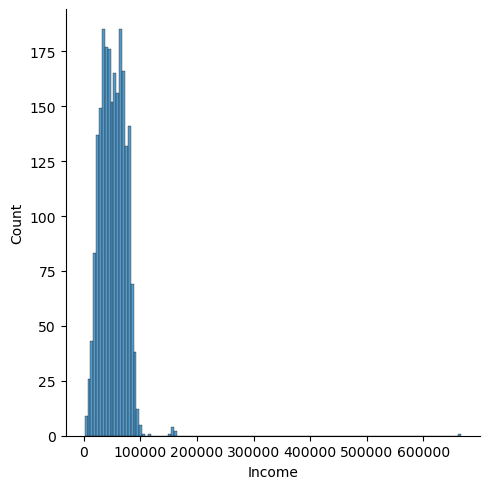

In [17]:
sns.displot(data=df,x='Income')

In [18]:
avg_mean = df['Income'].mean()

df = df.replace(np.nan, avg_mean)

In [22]:
print('Existen ',df.isnull().sum().sum(),'valores no existentes')

Existen  0 valores no existentes


# Análisis univariado

In [24]:
df.dtypes

Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
dtype: object

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2240.0,52247.251354,25037.797168,1730.0,35538.75,51741.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0


In [35]:
missing_values_count = df.isnull().sum()
print('Columnas que tienen valores nulos')
print('---------------------------------')
print(df.columns)
print(len(df.columns),'columnas')

cols_num = ['Year_Birth', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response']

Columnas que tienen valores nulos
---------------------------------
Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')
26 columnas


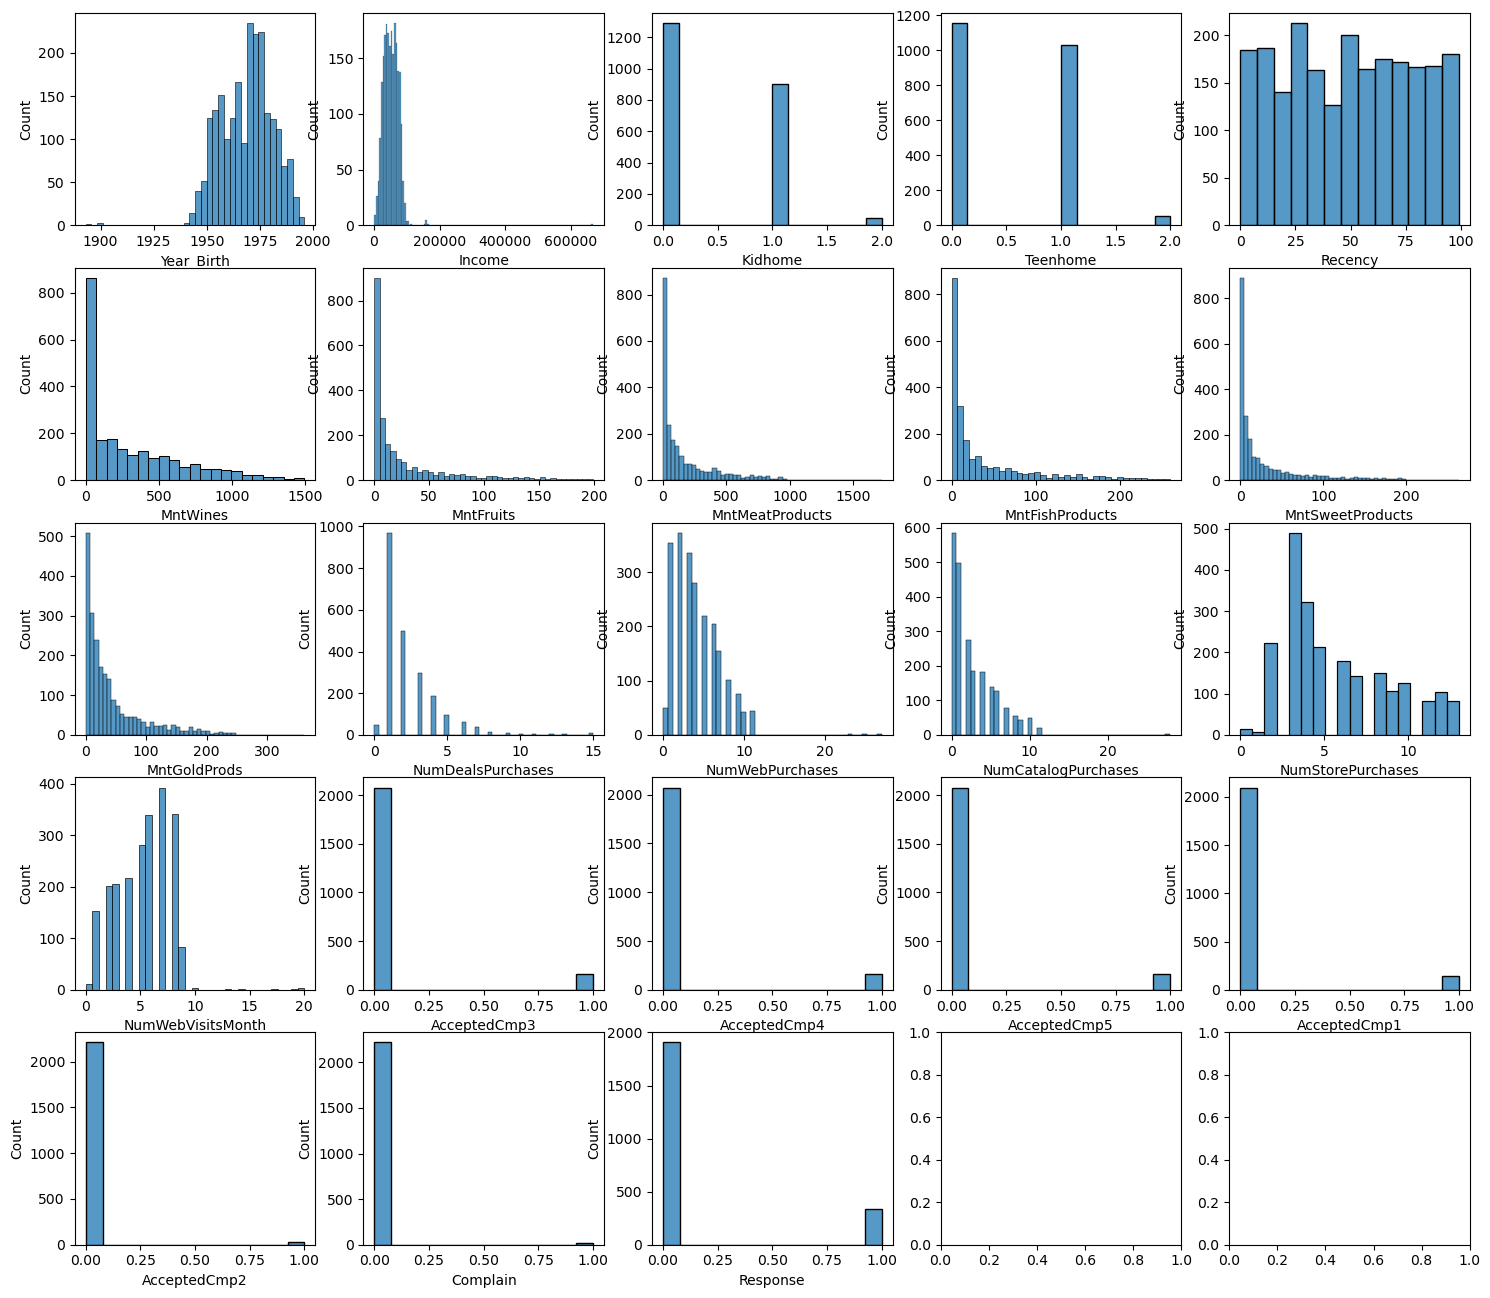

In [36]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

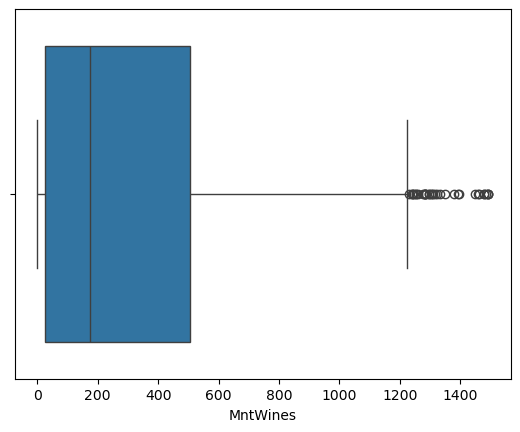

In [37]:
import seaborn as sns
ax = sns.boxplot(x=df['MntWines'])

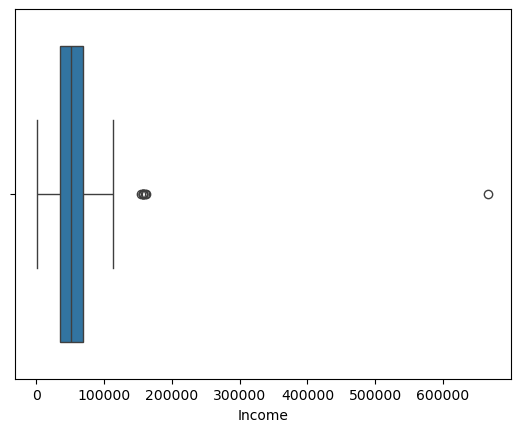

In [38]:
import seaborn as sns
ax = sns.boxplot(x=df['Income'])

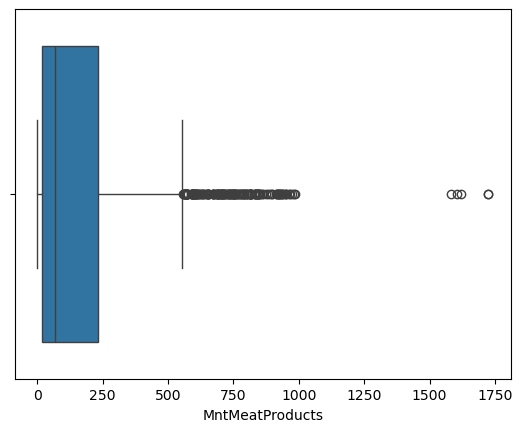

In [39]:
import seaborn as sns
ax = sns.boxplot(x=df['MntMeatProducts'])

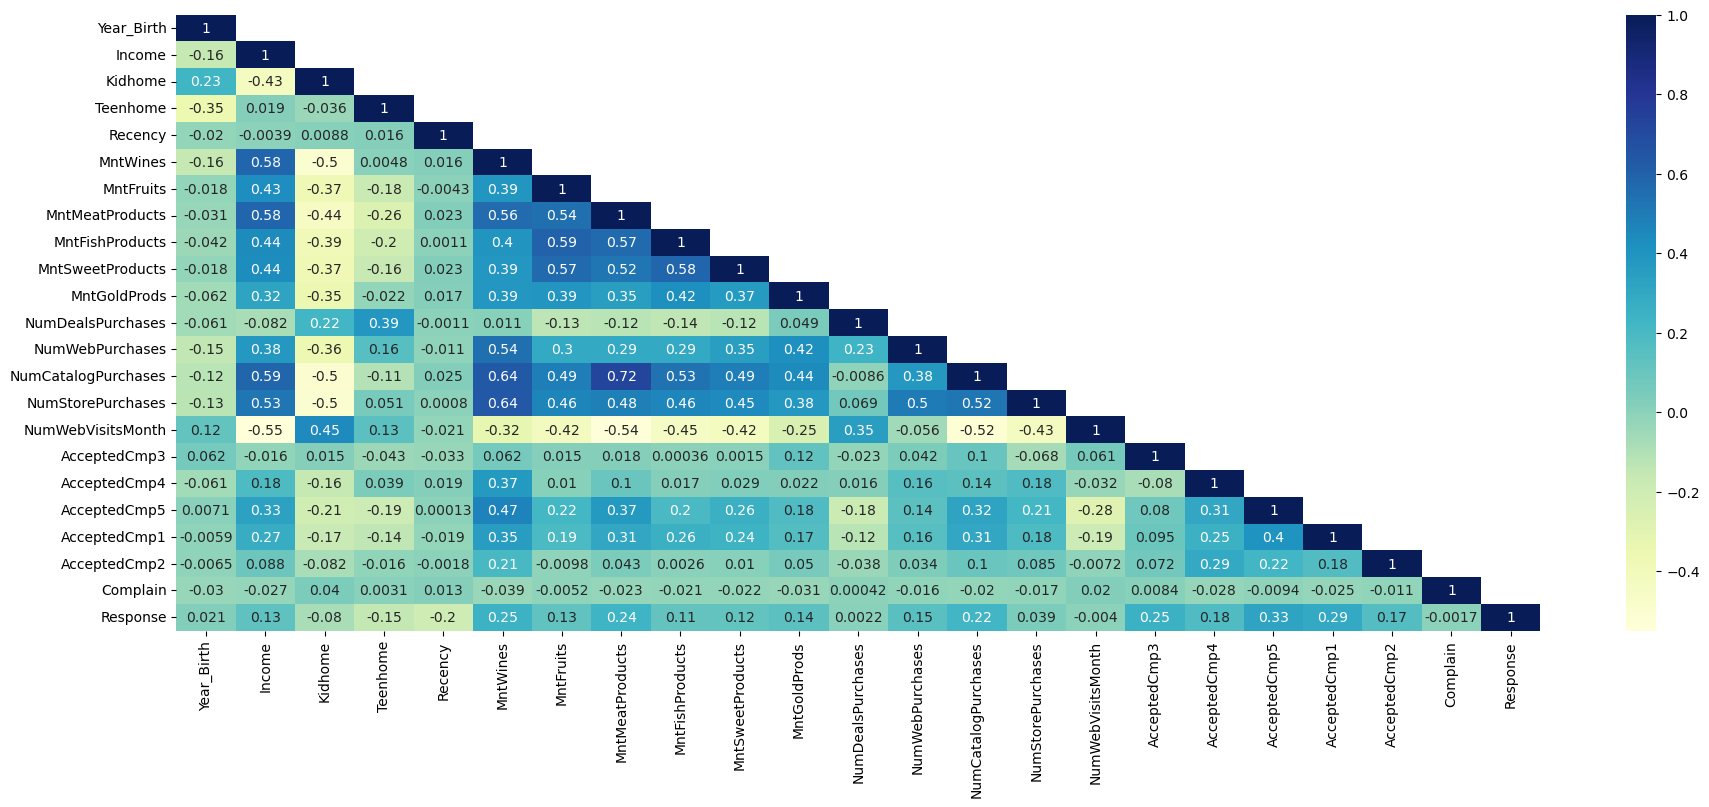

In [29]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [41]:
df.corr( numeric_only=True).style.background_gradient(cmap = 'Blues').set_properties(**{'front_size':'10px'})

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
Year_Birth,1.000000,-0.160942,0.230176,-0.352111,-0.019871,-0.157773,-0.017917,-0.030872,-0.041625,-0.018133,-0.061818,-0.060846,-0.145040,-0.121275,-0.128272,0.121139,0.061774,-0.060510,0.007123,-0.005930,-0.006539,-0.030128,0.021325
Income,-0.160942,1.000000,-0.425176,0.019018,-0.003946,0.576789,0.428747,0.577802,0.437497,0.436162,0.321978,-0.082290,0.380550,0.586725,0.526489,-0.549824,-0.016168,0.182791,0.334850,0.274921,0.087538,-0.027223,0.132756
Kidhome,0.230176,-0.425176,1.000000,-0.036133,0.008827,-0.496297,-0.372581,-0.437129,-0.387644,-0.370673,-0.349595,0.221798,-0.361647,-0.502237,-0.499683,0.447846,0.014674,-0.161600,-0.205634,-0.172339,-0.081716,0.040207,-0.080008
Teenhome,-0.352111,0.019018,-0.036133,1.000000,0.016198,0.004846,-0.176764,-0.261160,-0.204187,-0.162475,-0.021725,0.387741,0.155500,-0.110769,0.050695,0.134884,-0.042677,0.038886,-0.191050,-0.140090,-0.015605,0.003138,-0.154446
Recency,-0.019871,-0.003946,0.008827,0.016198,1.000000,0.016064,-0.004306,0.023056,0.001079,0.022670,0.016693,-0.001098,-0.010726,0.025110,0.000799,-0.021445,-0.032991,0.018826,0.000129,-0.019283,-0.001781,0.013231,-0.198437
MntWines,-0.157773,0.576789,-0.496297,0.004846,0.016064,1.000000,0.389637,0.562667,0.399753,0.386581,0.387516,0.010940,0.542265,0.635226,0.642100,-0.320653,0.062202,0.373286,0.472613,0.354133,0.205907,-0.039007,0.247254
MntFruits,-0.017917,0.428747,-0.372581,-0.176764,-0.004306,0.389637,1.000000,0.543105,0.594804,0.567164,0.392995,-0.132114,0.296735,0.487917,0.461758,-0.418383,0.014727,0.010152,0.215833,0.194748,-0.009773,-0.005166,0.125289
MntMeatProducts,-0.030872,0.577802,-0.437129,-0.261160,0.023056,0.562667,0.543105,1.000000,0.568402,0.523846,0.350609,-0.122415,0.293761,0.723827,0.479659,-0.539470,0.018272,0.102912,0.373769,0.309761,0.043033,-0.023483,0.236335
MntFishProducts,-0.041625,0.437497,-0.387644,-0.204187,0.001079,0.399753,0.594804,0.568402,1.000000,0.579870,0.422875,-0.139361,0.293681,0.534478,0.459855,-0.446003,0.000357,0.016843,0.199578,0.260762,0.002577,-0.020953,0.111331
MntSweetProducts,-0.018133,0.436162,-0.370673,-0.162475,0.022670,0.386581,0.567164,0.523846,0.579870,1.000000,0.369724,-0.120100,0.348544,0.490924,0.448756,-0.423294,0.001530,0.028641,0.259590,0.241818,0.009985,-0.022485,0.117372


# Analisis bivariado

In [81]:
df.groupby(['Marital_Status']).mean(numeric_only=True).T

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_35399/3890675083.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Marital_Status']).mean(numeric_only=True).T


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
ID,6051.5,2728.333333,5427.060345,5633.152778,5489.241667,5644.674138,5969.558442,5812.5
Year_Birth,1975.0,1973.000000,1966.275862,1969.579861,1971.489583,1967.746552,1958.558442,1973.0
Income,72365.5,43789.000000,52834.228448,51729.210370,51018.823463,53233.485792,56426.561706,48432.0
Kidhome,0.0,1.000000,0.413793,0.456019,0.464583,0.450000,0.233766,0.0
Teenhome,0.0,0.666667,0.590517,0.511574,0.406250,0.529310,0.636364,1.0
Recency,53.0,30.333333,49.487069,48.277778,49.506250,50.106897,49.142857,3.0
MntWines,355.5,184.666667,324.844828,299.480324,288.331250,306.825862,369.272727,322.0
MntFruits,84.5,4.000000,27.426724,25.734954,26.835417,25.350000,33.090909,3.0
MntMeatProducts,312.5,26.333333,150.206897,160.681713,182.108333,168.103448,189.285714,50.0
MntFishProducts,205.5,7.666667,35.043103,35.380787,38.216667,38.991379,51.389610,4.0


In [55]:
df.groupby(['Response']).median(numeric_only=True).T

Response,0,1
ID,5528.0,5133.0
Year_Birth,1970.0,1971.0
Income,50150.0,64090.0
Kidhome,0.0,0.0
Teenhome,1.0,0.0
Recency,52.0,30.0
MntWines,152.0,448.0
MntFruits,7.0,21.0
MntMeatProducts,56.0,174.5
MntFishProducts,11.0,25.0


In [56]:
df.drop('Z_Revenue',axis=1,inplace=True)
df.drop('Z_CostContact',axis=1,inplace=True)

In [57]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
591,7627,1975,Master,Married,92163.0,0,0,2012-12-12,25,817,...,11,5,2,0,0,1,1,0,0,1
806,7326,1971,Master,Married,56850.0,0,1,2014-03-23,83,34,...,1,3,2,0,0,0,0,0,0,0
864,4120,1975,2n Cycle,Single,49514.0,1,0,2013-12-17,61,88,...,1,4,7,0,0,0,0,0,0,0
1056,3846,1974,Graduation,Married,42557.0,0,1,2012-08-29,98,192,...,1,4,8,0,0,0,0,0,0,0
1061,3759,1958,Graduation,Together,65196.0,0,2,2013-07-25,34,743,...,6,11,5,1,0,0,0,0,0,0


In [58]:
df.loc[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,0,2,7,0,0,0,0,0,0,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,0,0,1,0,0,0,0,0,0,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,3,4,2,0,0,0,0,0,0,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,1,4,6,0,0,0,0,0,0,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,0,3,6,0,0,0,0,0,0,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,0,3,8,0,0,0,0,0,0,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,2,8,9,0,0,0,0,0,0,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,0,2,7,0,0,0,0,0,0,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,4,8,1,0,0,0,0,0,0,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,1,7,6,0,0,0,0,0,0,0


In [59]:
avg_mean = df['Income'].mean()
df = df.replace(np.nan,avg_mean)

In [60]:
df.loc[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response


In [61]:
print('Existen ', df.isnull().sum().sum(),'celdas en nulo' )

Existen  0 celdas en nulo


In [62]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
dtype: object

In [63]:
print(df['Education'].unique())
print(df['Marital_Status'].unique())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [64]:
df['Education'] = df['Education'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

In [65]:
df2 = df.copy()
df2.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
649,10928,1958,Graduation,Together,66886.0,0,1,2013-09-16,28,315,...,1,7,5,0,0,0,0,0,0,0
1319,8749,1984,Graduation,Together,37235.0,1,0,2014-02-01,68,20,...,1,2,4,0,0,0,0,0,0,0
1359,7275,1971,Master,Single,33316.0,1,1,2013-10-04,34,79,...,1,4,6,0,0,0,0,0,0,0
1850,4427,1995,2n Cycle,Single,83257.0,0,0,2012-09-18,56,536,...,10,12,6,1,0,1,0,0,1,1
668,11007,1968,PhD,Married,29187.0,1,0,2013-05-09,43,26,...,0,3,8,0,0,0,0,0,0,0


In [66]:
df2.drop('ID', axis=1, inplace =True)

In [67]:
df2.drop('Dt_Customer', axis=1, inplace =True)

In [68]:
df2['MntWines-log'] = np.log(df2['MntWines']+1)
df2['MntFruits-log'] = np.log(df2['MntFruits']+1)
df2['MntMeatProducts-log'] = np.log(df2['MntMeatProducts']+1)
df2['MntFishProducts-log'] = np.log(df2['MntFishProducts']+1)
df2['MntSweetProducts-log'] = np.log(df2['MntSweetProducts']+1)
df2['NumDealsPurchases-log'] = np.log(df2['NumDealsPurchases']+1)
df2['NumWebPurchases-log'] = np.log(df2['NumWebPurchases']+1)
df2['NumCatalogPurchases-log'] = np.log(df2['NumCatalogPurchases']+1)


In [69]:
df2.sample(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,MntWines-log,MntFruits-log,MntMeatProducts-log,MntFishProducts-log,MntSweetProducts-log,NumDealsPurchases-log,NumWebPurchases-log,NumCatalogPurchases-log
1483,1980,Graduation,Married,19107.0,1,0,49,2,4,9,...,0,0,1.098612,1.609438,2.302585,2.397895,1.791759,1.098612,0.693147,0.000000
297,1986,Master,Together,42386.0,1,0,43,65,4,16,...,0,0,4.189655,1.609438,2.833213,0.000000,1.609438,0.693147,1.386294,0.000000
1381,1956,2n Cycle,Together,54342.0,1,1,74,84,10,34,...,0,0,4.442651,2.397895,3.555348,2.484907,2.397895,1.609438,1.386294,0.693147
1782,1968,Graduation,Married,64590.0,0,0,98,920,138,168,...,0,0,6.825460,4.934474,5.129899,3.610918,3.850148,0.693147,2.302585,1.609438
382,1954,Graduation,Widow,27421.0,0,0,14,43,12,96,...,0,0,3.784190,2.564949,4.574711,4.369448,3.713572,1.386294,1.609438,0.693147
633,1960,2n Cycle,Single,32218.0,0,0,27,10,24,15,...,0,1,2.397895,3.218876,2.772589,2.639057,0.693147,0.693147,1.098612,0.693147
1349,1962,PhD,Divorced,85696.0,0,0,88,714,76,395,...,0,1,6.572283,4.343805,5.981414,4.762174,0.000000,0.693147,1.609438,1.945910
780,1974,PhD,Single,71466.0,0,0,86,412,12,546,...,0,0,6.023448,2.564949,6.304449,4.369448,5.209486,0.693147,1.609438,1.609438
831,1992,Graduation,Single,48789.0,0,0,94,351,16,156,...,0,0,5.863631,2.833213,5.056246,2.079442,1.791759,0.693147,1.945910,1.609438
1586,1952,Master,Together,40442.0,1,1,52,45,12,52,...,0,1,3.828641,2.564949,3.970292,3.258097,3.135494,1.609438,1.386294,0.693147


In [70]:
df2.sample(4)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,MntWines-log,MntFruits-log,MntMeatProducts-log,MntFishProducts-log,MntSweetProducts-log,NumDealsPurchases-log,NumWebPurchases-log,NumCatalogPurchases-log
2141,1971,Graduation,Married,35788.0,1,1,34,23,2,11,...,0,0,3.178054,1.098612,2.484907,1.386294,0.693147,1.098612,1.098612,0.000000
425,1953,Graduation,Married,48686.0,1,2,8,10,0,7,...,0,0,2.397895,0.000000,2.079442,1.098612,0.000000,0.693147,0.693147,0.000000
1767,1982,Graduation,Together,71853.0,0,0,29,358,108,413,...,0,0,5.883322,4.691348,6.025866,4.955827,4.584967,0.693147,1.098612,2.197225
1620,1965,PhD,Together,51717.0,0,1,55,98,1,17,...,0,0,4.595120,0.693147,2.890372,0.000000,0.693147,0.693147,1.386294,0.000000


In [71]:
df2.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'MntWines-log', 'MntFruits-log',
       'MntMeatProducts-log', 'MntFishProducts-log', 'MntSweetProducts-log',
       'NumDealsPurchases-log', 'NumWebPurchases-log',
       'NumCatalogPurchases-log'],
      dtype='object')

In [72]:
cols_num = ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'MntWines-log', 'MntFruits-log',
       'MntMeatProducts-log', 'MntFishProducts-log', 'MntSweetProducts-log',
       'NumDealsPurchases-log', 'NumWebPurchases-log',
       'NumCatalogPurchases-log']

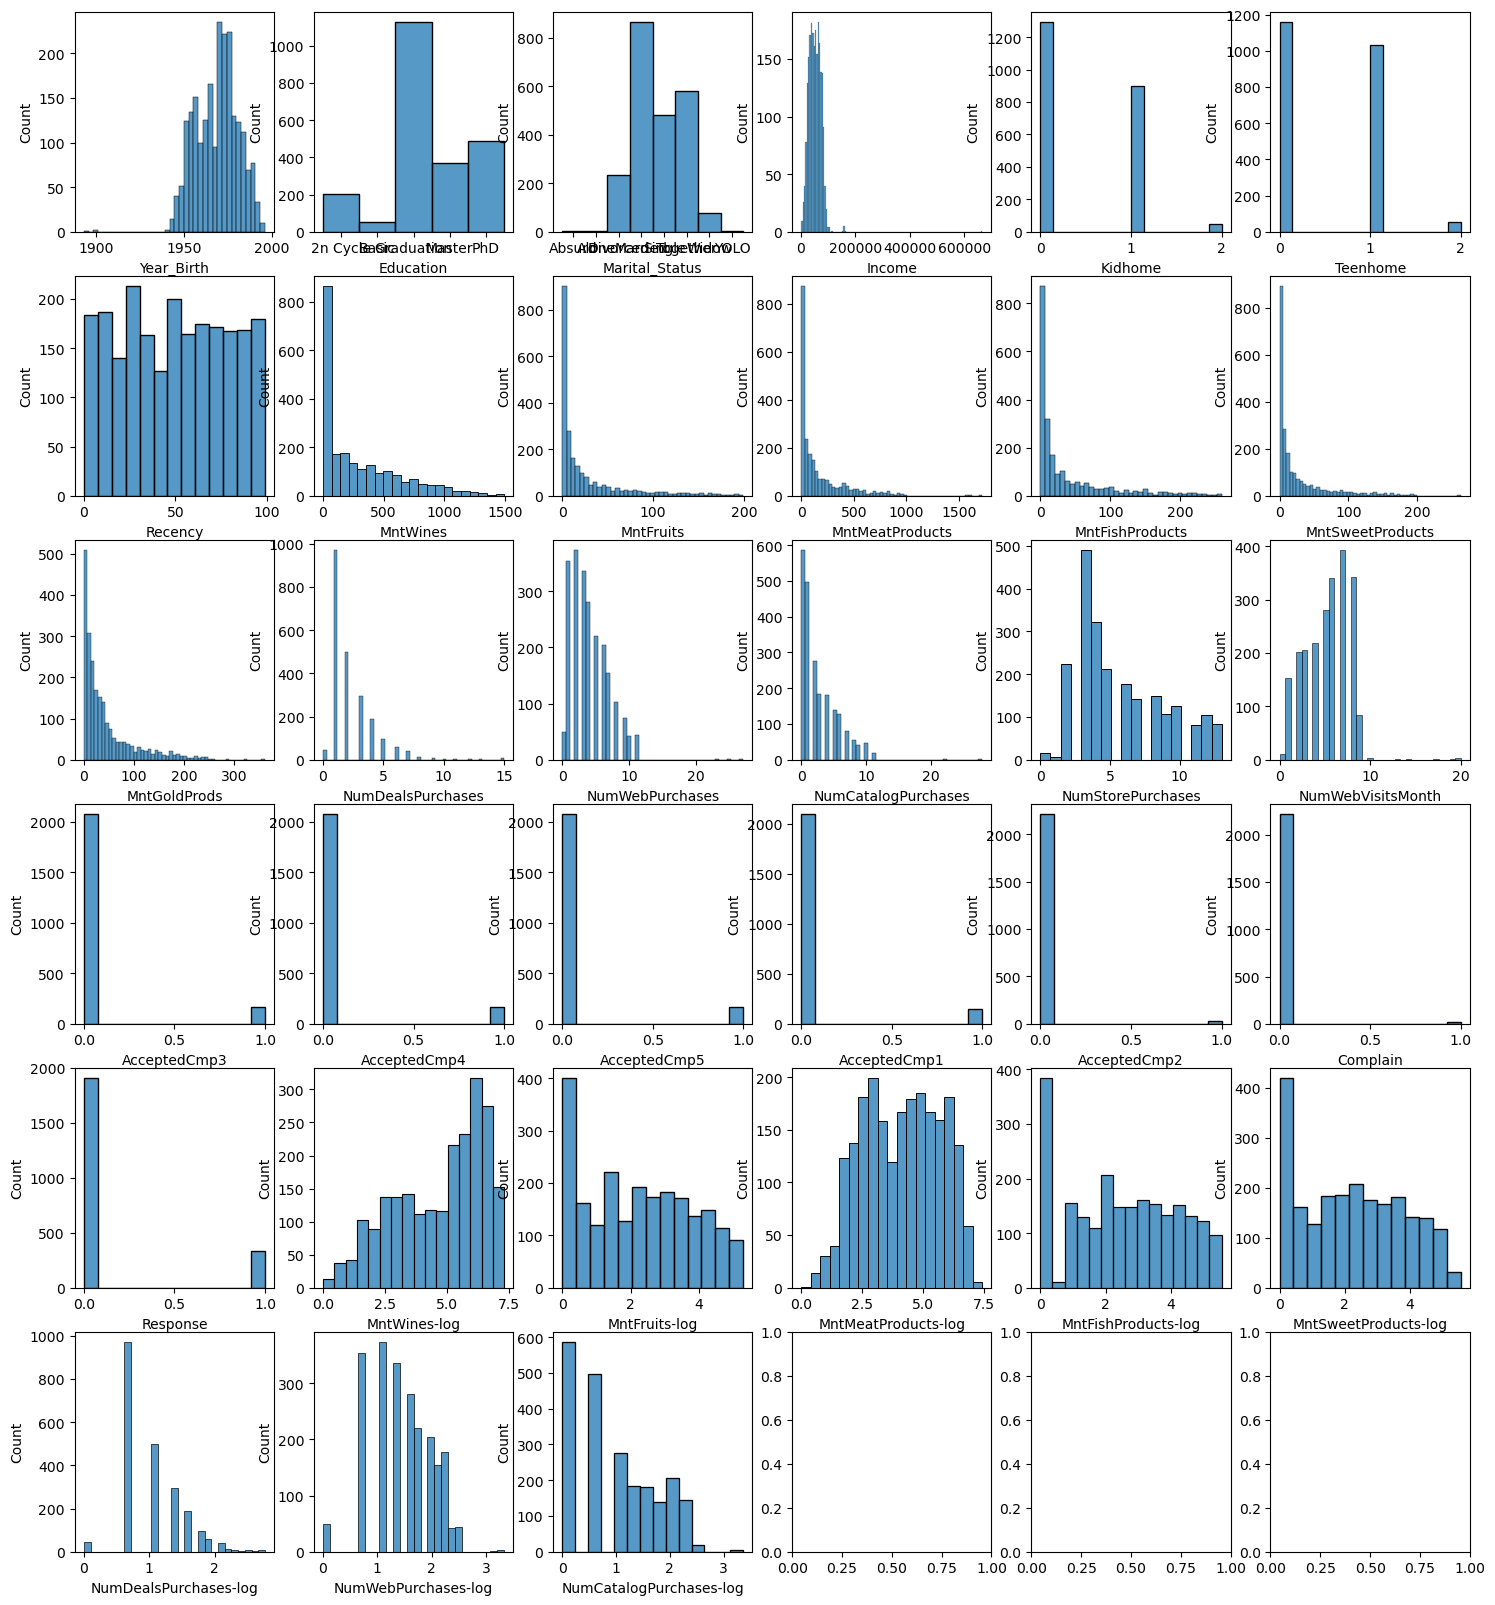

In [73]:
fig, axes = plt.subplots(nrows= 6, ncols=6, figsize=(18,20))
for i, column in enumerate(cols_num):
    sns.histplot(df2[column],ax=axes[i//6,i%6],kde=False)

In [74]:
from sklearn.model_selection import train_test_split

X = df2.drop('Response', axis=1)
y = df2['Response']

X = pd.get_dummies(X, drop_first = True)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=1)

In [75]:
X_train.head(3)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1747,1946,66835.0,0,0,21,620,26,195,34,17,...,False,True,False,False,False,True,False,False,False,False
115,1962,50785.0,1,1,27,64,1,21,0,1,...,True,False,False,False,False,False,True,False,False,False
1739,1971,42403.0,1,0,18,22,1,11,0,5,...,False,False,True,False,False,True,False,False,False,False


In [76]:
y_train.head(3)

1747    0
115     0
1739    0
Name: Response, dtype: int64

In [77]:
y_test.head(3)

779    0
389    0
510    0
Name: Response, dtype: int64

In [78]:
X_test.head(3)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
779,1971,72258.0,0,1,28,522,0,522,227,120,...,True,False,False,False,False,False,True,False,False,False
389,1968,83664.0,1,1,57,866,21,151,28,21,...,False,False,True,False,True,False,False,False,False,False
510,1981,39665.0,1,0,97,127,1,56,0,1,...,False,False,True,False,False,False,False,True,False,False


In [79]:
print("{0:0.2f}% data is in training set".format((len(X_train)/len(df2.index))*100))
print("{0:0.2f}% data is in test set".format((len(X_test)/len(df2.index))*100))

70.00% data is in training set
30.00% data is in test set


In [80]:
print("Original Personal Loan True Values : {0} ({1:02}%)".format(len(df2.loc[df2['Response']==1]),(len(df2.loc[df2['Response']==1])/len(df2.index))*100))
print("Original Personal Loan False Values : {0} ({1:02}%)".format(len(df2.loc[df2['Response']==0]),(len(df2.loc[df2['Response']==0])/len(df2.index))*100))
print("")
print("Training Personal Loan True Values : {0} ({1:02}%)".format(len(y_train.loc[y_train[:]==1]),(len(y_train.loc[y_train[:]==1])/len(y_train))*100))
print("Training Personal Loan False Values : {0} ({1:02}%)".format(len(y_train.loc[y_train[:]==0]),(len(y_train.loc[y_train[:]==0])/len(y_train))*100))
print("")
print("Training Personal Loan True Values : {0} ({1:02}%)".format(len(y_test.loc[y_test[:]==1]),(len(y_test.loc[y_test[:]==1])/len(y_test))*100))
print("Training Personal Loan False Values : {0} ({1:02}%)".format(len(y_test.loc[y_test[:]==0]),(len(y_test.loc[y_test[:]==0])/len(y_test))*100))


Original Personal Loan True Values : 334 (14.910714285714285%)
Original Personal Loan False Values : 1906 (85.08928571428571%)

Training Personal Loan True Values : 226 (14.41326530612245%)
Training Personal Loan False Values : 1342 (85.58673469387756%)

Training Personal Loan True Values : 108 (16.071428571428573%)
Training Personal Loan False Values : 564 (83.92857142857143%)
